### **1.Setup and load data**

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, RandomizedSearchCV, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


# configurations
pd.set_option("display.max_column",None)
sns.set_style("darkgrid")
RANDOM_STATE = 42
TARGET_COL="target"
CSV_PATH="C:\\Users\\anike\\OneDrive\\Arnav\\MedBuddy.ML\\dataset\\heart.csv"

In [122]:
df = pd.read_csv(CSV_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [123]:
print("Dataset shape",df.shape)

Dataset shape (1025, 14)


### **2. EDA**

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [125]:
for col in df.columns:
    print(df[col].value_counts().head(20))
    print("-"*50)
    print(df[col].value_counts(normalize=True).head(20))

age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
64    34
63    32
41    32
61    31
67    31
55    30
65    27
53    26
43    26
42    26
Name: count, dtype: int64
--------------------------------------------------
age
58    0.066341
57    0.055610
54    0.051707
59    0.044878
52    0.041951
51    0.038049
56    0.038049
62    0.036098
60    0.036098
44    0.035122
64    0.033171
63    0.031220
41    0.031220
61    0.030244
67    0.030244
55    0.029268
65    0.026341
53    0.025366
43    0.025366
42    0.025366
Name: proportion, dtype: float64
sex
1    713
0    312
Name: count, dtype: int64
--------------------------------------------------
sex
1    0.69561
0    0.30439
Name: proportion, dtype: float64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
--------------------------------------------------
cp
0    0.484878
2    0.277073
1    0.162927
3    0.075122
Name: proportion, dtype: float64
trestbps
120    128
130    123
1

In [126]:
print("Columns:",df.columns)

Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


In [127]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features= [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal",
    "target"
]

print("Numerical features",numerical_features)
print("Categorical features",categorical_features)

Numerical features ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [128]:
# missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [129]:
# encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))
    print("-"*50)


age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
64    34
63    32
41    32
61    31
67    31
55    30
65    27
53    26
43    26
42    26
Name: count, dtype: int64
--------------------------------------------------
sex
1    713
0    312
Name: count, dtype: int64
--------------------------------------------------
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
--------------------------------------------------
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
132     28
118     24
108     21
124     20
135     20
145     17
152     17
134     17
170     15
100     14
Name: count, dtype: int64
--------------------------------------------------
chol
204    21
234    21
197    19
212    18
254    17
269    16
177    14
282    14
240    14
211    13
226    13
239    13
243    13
203    12
233    12
229    12
220    12
249    11
256    11
230    11
Name: count, 

- **No missing values present**

In [130]:
# duplicates 
masked_duplicates = df.duplicated()
num_duplicates = masked_duplicates.sum()
print(f"The no. of duplicates rows are: {num_duplicates}")

The no. of duplicates rows are: 723


- **dataset contains 1,500 rows, of which 723 are duplicate records. These records are retained because identical observations may represent valid, independent real-world cases rather than wrong entries**

In [131]:
# target distribution 
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True)*100)

target
1    526
0    499
Name: count, dtype: int64
--------------------------------------------------
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


In [132]:
# quassi constant, constant and ID like columns 

n_rows = len(df)
unique = df.nunique()

constant_cols = unique[unique==1].index.to_list()

quassi_constant_cols = []
id_like_cols=[]

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        quassi_constant_cols.append(col)

for col in df.columns:
    if df[col].nunique()==n_rows:
        id_like_cols.append(col)

print(f"Constant columns are: {constant_cols}")
print(f"Quassi constant columns are: {quassi_constant_cols}")
print(f"ID like columns are: {id_like_cols}")        

Constant columns are: []
Quassi constant columns are: []
ID like columns are: []


In [133]:
# descriptive analysis
df[numerical_features].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.754146
std,9.072290,17.516718,51.59251,23.005724,1.175053,1.030798
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,0.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,4.000000


### **3. Data visualization**

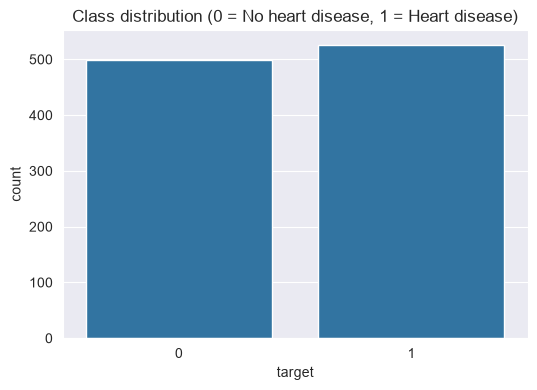

In [134]:
# visualize target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Class distribution (0 = No heart disease, 1 = Heart disease)")
plt.show()

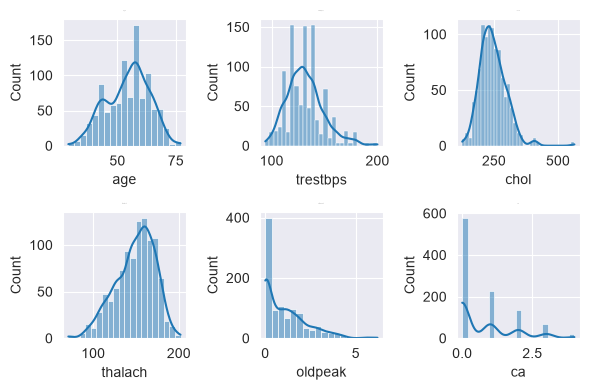

In [135]:
# histogram - distribution - numerical features
fig, axes = plt.subplots(2,3, figsize=(6,4))
axes = axes.flatten()

for i,col in enumerate(numerical_features):
    sns.histplot(x=df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=0.8)

plt.tight_layout()
plt.show()    

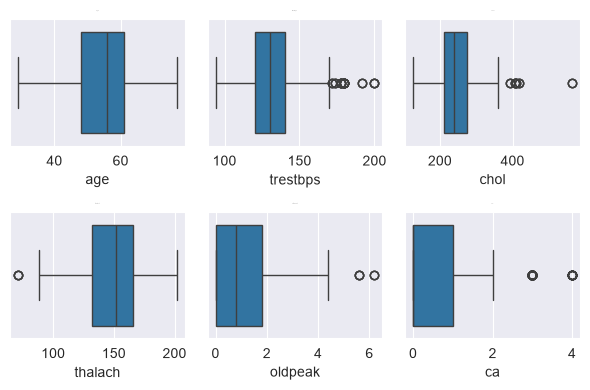

In [136]:
# outliers - distribution - numerical features
fig, axes = plt.subplots(2,3, figsize=(6,4))
axes = axes.flatten()

for i,col in enumerate(numerical_features):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col, fontsize=0.8)

plt.tight_layout()
plt.show()    

- **No significant outliers present**

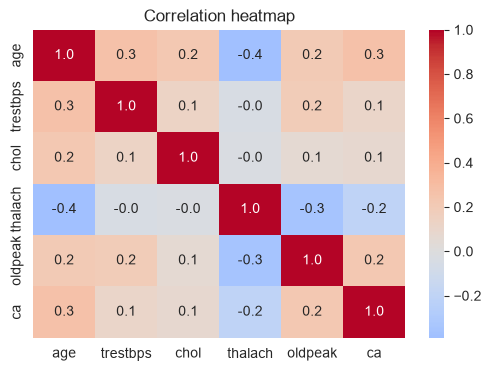

In [137]:
# correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data=df[numerical_features].corr(),cmap="coolwarm",annot=True,center=0,fmt=".1f")
plt.title("Correlation heatmap")
plt.show()

- **No highly correlated columns**

### **4. Data preprocessing**

In [138]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# signature for each feature row 
row_signature = pd.util.hash_pandas_object(X, index=False)

In [139]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=row_signature)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Original shape: {df.shape}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Original shape: (1025, 14)
Train shape: (869, 13)
Test shape: (156, 13)


In [140]:
categorical_features

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

In [141]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print("-"*50)

sex
1    69.560976
0    30.439024
Name: proportion, dtype: float64
--------------------------------------------------
cp
0    48.487805
2    27.707317
1    16.292683
3     7.512195
Name: proportion, dtype: float64
--------------------------------------------------
fbs
0    85.073171
1    14.926829
Name: proportion, dtype: float64
--------------------------------------------------
restecg
1    50.048780
0    48.487805
2     1.463415
Name: proportion, dtype: float64
--------------------------------------------------
exang
0    66.341463
1    33.658537
Name: proportion, dtype: float64
--------------------------------------------------
slope
1    47.024390
2    45.756098
0     7.219512
Name: proportion, dtype: float64
--------------------------------------------------
thal
2    53.073171
3    40.000000
1     6.243902
0     0.682927
Name: proportion, dtype: float64
--------------------------------------------------
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64
------

In [142]:
X_train.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')

### **5. Baseline model**

In [143]:
baseline_model = Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",LogisticRegression())
    ]
)

In [144]:
baseline_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [145]:
# reusable evaluation function
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    # predictions 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy 
    train_acc = accuracy_score(y_train, y_train_pred)*100
    test_acc = accuracy_score(y_test, y_test_pred)*100

    # results
    print(f"{model_name} - Train accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test accuracy: {test_acc:.2f}%")

    print("-"*50)

    print("Train classification report")
    print(classification_report(y_train, y_train_pred))

    print("-"*50)

    print("Test classification report")
    print(classification_report(y_test, y_test_pred))

In [146]:
evaluate_classifier(baseline_model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, model_name="Logistic regression")


Logistic regression - Train accuracy: 84.23%
Logistic regression - Test accuracy: 83.33%
--------------------------------------------------
Train classification report
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       430
           1       0.81      0.89      0.85       439

    accuracy                           0.84       869
   macro avg       0.85      0.84      0.84       869
weighted avg       0.85      0.84      0.84       869

--------------------------------------------------
Test classification report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



### **6. Model Selection**

In [149]:
models = {
    "Logistic Regression":LogisticRegression(random_state=RANDOM_STATE),
    "SVM":SVC(random_state=RANDOM_STATE),
    "XGboost":XGBClassifier(),
    "random forest":RandomForestClassifier(random_state=RANDOM_STATE)
}

In [150]:
groups = pd.util.hash_pandas_object(X_train, index=False)

k = 5
cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [152]:
for name, model in models.items():

    recall_scores = []
    f1_scores = []

    for tr_idx, te_idx in cv.split(X_train, y_train, groups=groups):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        pipeline = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model",model)
            ]
        )

        pipeline.fit(X_tr, y_tr)
        pred = pipeline.predict(X_te)

        recall_scores.append(round(recall_score(y_te, pred),2))
        f1_scores.append(round(f1_score(y_te, pred),2))

    print("Model name:",name)
    print("recall values:",recall_scores)
    print("f1 scores:",f1_scores)
    print("\nMean Recall score:",round(float(np.mean(recall_scores)),2))
    print("Mean F1 score:",round(float(np.mean(f1_scores)),2))  
    print("-"*50)

Model name: Logistic Regression
recall values: [0.9, 0.75, 0.93, 0.89, 0.82]
f1 scores: [0.87, 0.75, 0.91, 0.82, 0.75]

Mean Recall score: 0.86
Mean F1 score: 0.82
--------------------------------------------------
Model name: SVM
recall values: [0.79, 0.72, 0.82, 0.96, 0.72]
f1 scores: [0.76, 0.76, 0.84, 0.83, 0.69]

Mean Recall score: 0.8
Mean F1 score: 0.78
--------------------------------------------------
Model name: XGboost
recall values: [0.82, 0.72, 0.9, 0.97, 0.82]
f1 scores: [0.79, 0.78, 0.86, 0.87, 0.72]

Mean Recall score: 0.85
Mean F1 score: 0.8
--------------------------------------------------
Model name: random forest
recall values: [0.93, 0.82, 0.9, 0.92, 0.82]
f1 scores: [0.88, 0.81, 0.87, 0.87, 0.75]

Mean Recall score: 0.88
Mean F1 score: 0.84
--------------------------------------------------


- **Best model : Randomforest**

### **7. Hyperparameter tuning**

In [153]:
best_model = Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1))
    ]
)

In [154]:
param_dict = {
    "model__n_estimators": randint(400, 1200),
    "model__max_depth": [3, 4, 5, 6],
    "model__min_samples_split": randint(10, 40),
    "model__min_samples_leaf": randint(4, 20),
    "model__max_features": [0.25, 0.35, 0.5, "sqrt"],
    "model__bootstrap": [True],
    "model__max_samples": uniform(0.6, 0.35),
    "model__ccp_alpha": uniform(0.0, 0.02)
}

In [156]:
randomizedsearch = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=param_dict,
    n_iter=60,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=-1
)

In [158]:
randomizedsearch.fit(X_train, y_train, groups=groups)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....0025EA9DBF890>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a 

In [159]:
print("Hyperparameter tuning results")
print("Best params",randomizedsearch.best_params_)
print("Best score",randomizedsearch.best_score_)

Hyperparameter tuning results
Best params {'model__bootstrap': True, 'model__ccp_alpha': np.float64(0.00176985004103839), 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__max_samples': np.float64(0.6158295511186883), 'model__min_samples_leaf': 11, 'model__min_samples_split': 30, 'model__n_estimators': 1119}
Best score 0.8484741292730688


### **8. Retrain with best params**

In [160]:
rfc = Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=randomizedsearch.best_params_["model__n_estimators"],
            max_depth=randomizedsearch.best_params_["model__max_depth"],
            min_samples_split=randomizedsearch.best_params_["model__min_samples_split"],
            min_samples_leaf=randomizedsearch.best_params_["model__min_samples_leaf"],
            max_features=randomizedsearch.best_params_["model__max_features"],
            bootstrap=randomizedsearch.best_params_["model__bootstrap"]
        ))
    ]
)

In [161]:
rfc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [162]:
evaluate_classifier(model=rfc, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, model_name="Random Forest - Best model")


Random Forest - Best model - Train accuracy: 91.25%
Random Forest - Best model - Test accuracy: 81.41%
--------------------------------------------------
Train classification report
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       430
           1       0.89      0.94      0.92       439

    accuracy                           0.91       869
   macro avg       0.91      0.91      0.91       869
weighted avg       0.91      0.91      0.91       869

--------------------------------------------------
Test classification report
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        69
           1       0.80      0.90      0.84        87

    accuracy                           0.81       156
   macro avg       0.82      0.80      0.81       156
weighted avg       0.82      0.81      0.81       156



### **9. Predictive system**

In [199]:
def predict_heart_disease(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )

    prediction = rfc.predict(input_df)[0]
    probability = rfc.predict_proba(input_df)[0][1]

    print(f"Predicted class: {prediction}")
    print(f"Heart disease risk probability {probability:.2%} ")

    if prediction == 1:
        print("Diagnosis: High risk of heart disease ⚠️")
    else:
        print("Diagnosis: Low risk of heart disease 💚")    

    return prediction, probability    

In [200]:
y_test[y_test==1].head()

24    1
38    1
57    1
68    1
84    1
Name: target, dtype: int64

In [201]:
y_test[y_test==0].head()

4     0
8     0
17    0
43    0
53    0
Name: target, dtype: int64

In [202]:
test_1 = X_test.loc[24].to_list()
predict_heart_disease(test_1)

Predicted class: 1
Heart disease risk probability 96.53% 
Diagnosis: High risk of heart disease ⚠️


(np.int64(1), np.float64(0.9653486473533656))

In [212]:
test_2 = X_test.loc[8].to_list()
predict_heart_disease(test_2)

Predicted class: 0
Heart disease risk probability 39.96% 
Diagnosis: Low risk of heart disease 💚


(np.int64(0), np.float64(0.3995954150549672))